# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties

from scipy.interpolate import PchipInterpolator

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [ ]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

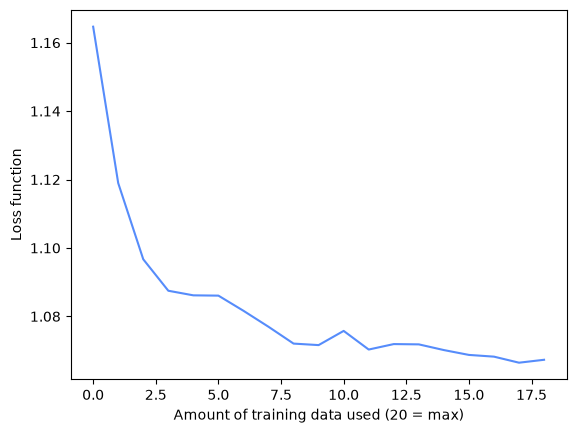

In [ ]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [ ]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

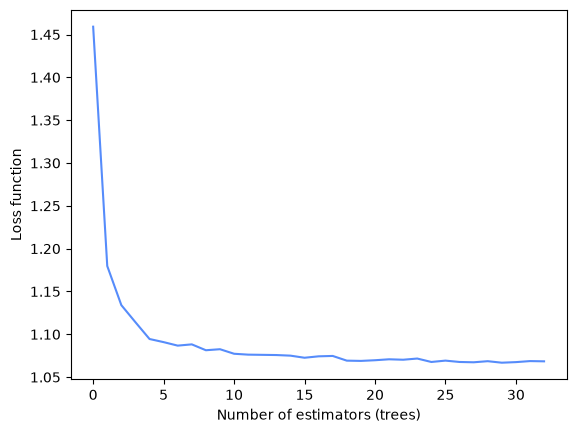

In [ ]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

Cut the "number of estimators" plot; keep "amount of training data."

Why? The n_estimators curve just shows the standard RF pattern — RMSE drops fast then plateaus, because averaging more trees reduces variance with sharply diminishing returns. That's expected behavior, not new information — you learn "pick something like 50-100 trees" and move on. The training-data-size curve (a learning curve) is more useful: it tells you whether the model is still improving with more data or has flattened out, which is a real, actionable signal about whether it's worth collecting more data. That's the more interesting/important story, so it's the one to keep.
On the x-axis bug: both plots have the same underlying problem — plt.plot(rmse_lst) and plt.plot(num_trees_lst) only pass the y-values, so matplotlib plots them against the point index (0, 1, 2, ...), not the actual quantity varied.

- First plot: index runs 0–18 (19 points, sizes 500 to 9500 in steps of 500). The label "20 = max" is an approximation that happens to roughly work since the step size is constant, but it's technically off (true max index is 18, corresponding to 9500/10000 data, not the full set).
- Second plot: index runs 0–32, but n_estimators actually goes 1, 4, 7, ..., 97. Labeling the x-axis "Number of estimators" is flatly wrong here — the tick values don't match real tree counts at all.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

## All datasets

In [ ]:
# Shared imports for classification modeling (used by all datasets below)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              mean_squared_error, mean_absolute_error, r2_score,
                              explained_variance_score)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
pd.set_option('display.max_columns', 100)

## Dataset 1: Malware

### Setup

In [ ]:
# Load the dataset
files = [
    "malware_benign_1.csv",
    "malware_benign_2.csv",
    "malware_benign_3.csv",
    "malware_benign_4.csv",
    "malware_benign_5.csv",
    "malware_benign_6.csv",
    "malware_benign_7.csv",
    "malware_benign_8.csv",
    "malware_benign_9.csv",
    "malware_benign_10.csv",
    "malware_benign_11.csv",
    "malware_benign_12.csv",
    "malware_benign_13.csv",
    "malware_benign_14.csv",
    "malware_benign_15.csv",
    "ransomware_wannalocker_1.csv",
    "ransomware_wannalocker_2.csv",
    "ransomware_wannalocker_3.csv",
    "ransomware_wannalocker_4.csv",
    "ransomware_wannalocker_5.csv",
    "ransomware_wannalocker_6.csv",
    "ransomware_wannalocker_7.csv",
    "ransomware_wannalocker_8.csv",
    "ransomware_wannalocker_9.csv"
]

dfs = []
for f in files:
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

ransomware_df = pd.concat(dfs, ignore_index=True)
print(ransomware_df.shape)

(37839, 85)


In [ ]:
# Print the dataset
ransomware_df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,0,1,0,0,0,0,1.0,403.642857,179.333333,571.875000,200,0,0,0,0,0,0,6,1076,8,4575,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16/06/2017 03:55:52,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16/06/2017 03:55:53,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,1,0,0,1,0,0,0,1.0,31.000000,31.000000,0.000000,32,0,0,0,0,0,0,1,31,1,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16/06/2017 03:55:58,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,0,1,0,0,0,0,1.0,124.615385,218.833333,43.857143,200,0,0,0,0,0,0,6,1313,7,307,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [ ]:
# Map the label column to numeric classes
print("Before:", ransomware_df['Label'].unique())

ransomware_df['Label'] = np.where(ransomware_df['Label'].str.strip().str.upper() == 'BENIGN', 0, 1)

print("After:", ransomware_df['Label'].unique())
ransomware_df['Label'].value_counts()

Before: <StringArray>
['BENIGN', 'RANSOMWARE_WANNALOCKER']
Length: 2, dtype: str
After: [0 1]


Label
1    29769
0     8070
Name: count, dtype: int64

In [ ]:
# Drop duplicate rows
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 0 duplicate rows -> 37839 rows remaining


In [ ]:
# Drop null & NaN values
before = len(ransomware_df)
ransomware_df = ransomware_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(ransomware_df)} rows with null/NaN values -> {len(ransomware_df)} rows remaining")

Dropped 0 rows with null/NaN values -> 37839 rows remaining


In [ ]:
# Drop negative values
before = len(ransomware_df)
numeric_cols = ransomware_df.select_dtypes(include=[np.number]).columns

# Init_Win_bytes_backward uses -1 as a sentinel meaning "no backward-direction"
# "window observed" (not invalid data), so it is excluded from the negative-value check.
negative_check_cols = numeric_cols.drop('Init_Win_bytes_backward')

negative_mask = (ransomware_df[negative_check_cols] < 0).any(axis=1)
ransomware_df = ransomware_df[~negative_mask]
print(f"Dropped {before - len(ransomware_df)} rows containing negative values (excluding Init_Win_bytes_backward) -> {len(ransomware_df)} rows remaining")

Dropped 8678 rows containing negative values (excluding Init_Win_bytes_backward) -> 29161 rows remaining


In [ ]:
# Drop non-numeric columns
non_numeric_cols = ransomware_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

ransomware_df = ransomware_df.drop(columns=non_numeric_cols)
print(ransomware_df.shape)

Dropping non-numeric columns: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
(29161, 81)


In [ ]:
# Drop perfectly correlated columns
corr_matrix = ransomware_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

ransomware_df = ransomware_df.drop(columns=perfectly_correlated)
print(ransomware_df.shape)

Dropping 8 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(29161, 73)


In [ ]:
# Drop duplicate rows (post feature engineering)
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 0 duplicate rows -> 29161 rows remaining


In [ ]:
# Print clean dataset
ransomware_df.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,51023,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,1,0,0,0,0,1.0,403.642857,0,0,0,0,0,0,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,51023,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,34259,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,55509,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,0,0,1,0,0,0,1.0,31.000000,0,0,0,0,0,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,44852,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,1,0,0,0,0,1.0,124.615385,0,0,0,0,0,0,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
# Sanity check
print("Any nulls left:", ransomware_df.isnull().values.any())
print("Any negatives left:", (ransomware_df < 0).values.any())
print("Any duplicate rows left:", ransomware_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in ransomware_df.dtypes))
print("\nFinal shape:", ransomware_df.shape)
print("\nLabel counts:")
print(ransomware_df['Label'].value_counts())

Any nulls left: False
Any negatives left: True
Any duplicate rows left: False
All columns numeric: True

Final shape: (29161, 73)

Label counts:
Label
1    22863
0     6298
Name: count, dtype: int64


In [ ]:
# Export cleaned data to CSV
ransomware_df.to_csv("ransomware_combined_clean.csv", index=False)
print("Saved ransomware_combined_clean.csv")

Saved ransomware_combined_clean.csv


### Definition

In [ ]:
# Definition
target = ransomware_df['Label']
X = ransomware_df.drop(columns=['Label'])

### Class balance

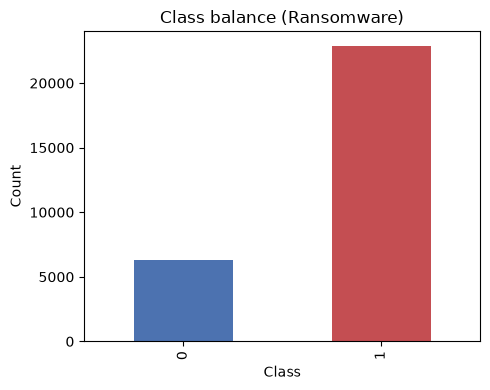

Label
1    0.784027
0    0.215973
Name: proportion, dtype: float64


In [ ]:
# Class balance
fig, ax = plt.subplots(figsize=(5, 4))
target.value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_title('Class balance (Ransomware)')
plt.tight_layout()
plt.show()

print(target.value_counts(normalize=True).rename('proportion'))

### Train/test split

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, target, test_size=0.25, random_state=RANDOM_STATE, stratify=target
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (21870, 72)  Test shape: (7291, 72)


### Evaluation function (helper function)

In [ ]:
# Evaluation function
results = {}

def evaluate(name, y_true, y_pred, y_score):
    mse = mean_squared_error(y_true, y_score)
    res = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "MAE": mean_absolute_error(y_true, y_score),
        "R2": r2_score(y_true, y_score),
        "Explained Var.": explained_variance_score(y_true, y_score),
    }
    results[name] = res
    for k, v in res.items():
        print(f"{k:>10}: {v:.4f}")
    return res

### Models

#### Linear regression

##### Cross-validation

In [ ]:
# Cross-validation
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

lin_scores_cv = cross_val_score(lin_reg, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Linear Regression 5-fold CV R^2: {lin_scores_cv.mean():.4f} +/- {lin_scores_cv.std():.4f}")

Linear Regression 5-fold CV R^2: 0.0634 +/- 0.0063


##### Hyperparameter tuning

In [ ]:
# Hyperparameter tuning
# Ordinary least squares linear regression has no hyperparameters to tune.

##### Performance metrics

In [ ]:
# Performance metrics
lin_pred_continuous = lin_reg.predict(X_test_scaled)
lin_pred_class = (lin_pred_continuous >= 0.5).astype(int)

print("Test set performance (thresholded at 0.5):")
evaluate("Linear Regression", y_test, lin_pred_class, lin_pred_continuous)

Test set performance (thresholded at 0.5):
  Accuracy: 0.7932
 Precision: 0.7941
    Recall: 0.9939
        F1: 0.8828
   ROC-AUC: 0.6585
       MSE: 0.1582
      RMSE: 0.3977
       MAE: 0.3179
        R2: 0.0661
Explained Var.: 0.0662


{'Accuracy': 0.7931696612261693,
 'Precision': 0.7941012021246855,
 'Recall': 0.9938768369489154,
 'F1': 0.8828282828282829,
 'ROC-AUC': 0.6584524642607218,
 'MSE': 0.15815631798795873,
 'RMSE': 0.39768871996570226,
 'MAE': 0.31786065710941114,
 'R2': 0.06612668909810837,
 'Explained Var.': 0.06615655483152894}

#### Logistic regression

##### Cross-validation

In [ ]:
# Cross-validation
log_reg = LogisticRegression(max_iter=300, solver="lbfgs", random_state=RANDOM_STATE)

cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=3, scoring='f1', n_jobs=-1)
print(f"Logistic Regression 3-fold CV F1 (untuned): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Logistic Regression 3-fold CV F1 (untuned): 0.8812 +/- 0.0005


##### Hyperparamter tuning

In [ ]:
# Hyperparameter tuning
param_grid = {"C": [0.1, 1, 10], "penalty": ["l2"], "solver": ["lbfgs"]}
grid = GridSearchCV(log_reg, param_grid, cv=3, scoring="f1", n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.4f}")

best_log_reg = grid.best_estimator_

Best params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1: 0.8817


##### Performance metrics

In [ ]:
# Performance metrics
log_pred = best_log_reg.predict(X_test_scaled)
log_score = best_log_reg.predict_proba(X_test_scaled)[:, 1]

print("Test set performance:")
evaluate("Logistic Regression", y_test, log_pred, log_score)

Test set performance:
  Accuracy: 0.7943
 Precision: 0.7958
    Recall: 0.9921
        F1: 0.8832
   ROC-AUC: 0.6564
       MSE: 0.1562
      RMSE: 0.3953
       MAE: 0.3110
        R2: 0.0775
Explained Var.: 0.0775


{'Accuracy': 0.7942669044026882,
 'Precision': 0.7958181307886613,
 'Recall': 0.9921273617914625,
 'F1': 0.8831957638997041,
 'ROC-AUC': 0.6563878614193519,
 'MSE': 0.1562303081177358,
 'RMSE': 0.3952597982564579,
 'MAE': 0.31098668072441005,
 'R2': 0.07749929334950323,
 'Explained Var.': 0.07753009614959316}

#### Random forest

##### Cross-validation

In [ ]:
# Cross validation
rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1)

cv_scores = cross_val_score(rf, X_train, y_train, cv=3, scoring='f1', n_jobs=1)
print(f"Random Forest 3-fold CV F1 (untuned): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Random Forest 3-fold CV F1 (untuned): 0.9285 +/- 0.0011


##### Hyperparameter tuning

In [ ]:
# Hyperparameter tuning
rf_param_dist = {'n_estimators': [100, 150], 'max_depth': [10, 15, 20], 'min_samples_leaf': [1, 2], 'max_features': ['sqrt', 'log2']}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
                                rf_param_dist, n_iter=4, cv=3, scoring="f1",
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print(f"Best CV F1: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_

Best params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV F1: 0.9285


##### Performance metrics

In [ ]:
# Performance metrics
rf_pred = best_rf.predict(X_test)
rf_score = best_rf.predict_proba(X_test)[:, 1]

print("Test set performance:")
evaluate("Random Forest", y_test, rf_pred, rf_score)

Test set performance:
  Accuracy: 0.9023
 Precision: 0.9084
    Recall: 0.9736
        F1: 0.9399
   ROC-AUC: 0.9395
       MSE: 0.0771
      RMSE: 0.2777
       MAE: 0.1791
        R2: 0.5447
Explained Var.: 0.5447


{'Accuracy': 0.9023453572898094,
 'Precision': 0.9084231145935358,
 'Recall': 0.9735829251224632,
 'F1': 0.9398750211112987,
 'ROC-AUC': 0.9394502204894085,
 'MSE': 0.07710187223347913,
 'RMSE': 0.2776722388599176,
 'MAE': 0.179094130405762,
 'R2': 0.5447328212022755,
 'Explained Var.': 0.5447341445945829}

##### Feature importance

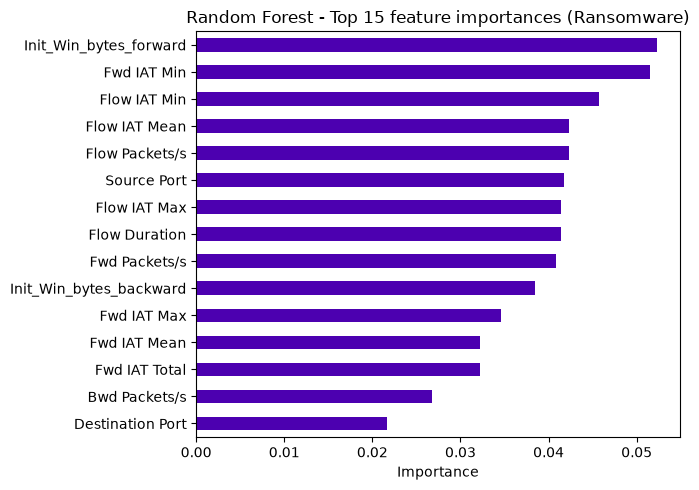

In [ ]:
# Feature importance
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
importances.sort_values().plot(kind='barh', ax=ax, color='#4C00B0')
ax.set_title('Random Forest - Top 15 feature importances (Ransomware)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

#### Gradient boosting

##### Cross-validation

In [ ]:
# Cross-validation
gb = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

cv_scores = cross_val_score(gb, X_train, y_train, cv=3, scoring='f1', n_jobs=1)
print(f"Gradient Boosting 3-fold CV F1 (untuned): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Gradient Boosting 3-fold CV F1 (untuned): 0.9309 +/- 0.0018


##### Hyperparameter tuning

In [ ]:
# Hyperparameter tuning
gb_param_dist = {
    "max_iter": [100, 150, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5, None],
}
gb_search = RandomizedSearchCV(gb, gb_param_dist, n_iter=5, cv=3, scoring="f1",
                                random_state=RANDOM_STATE, n_jobs=-1)
gb_search.fit(X_train, y_train)

print("Best params:", gb_search.best_params_)
print(f"Best CV F1: {gb_search.best_score_:.4f}")

best_gb = gb_search.best_estimator_

Best params: {'max_iter': 100, 'max_depth': 5, 'learning_rate': 0.2}
Best CV F1: 0.9306


##### Performance metrics

In [ ]:
# Performance metrics
gb_pred = best_gb.predict(X_test)
gb_score = best_gb.predict_proba(X_test)[:, 1]

print("Test set performance:")
evaluate("Gradient Boosting", y_test, gb_pred, gb_score)

Test set performance:
  Accuracy: 0.8963
 Precision: 0.9022
    Recall: 0.9732
        F1: 0.9364
   ROC-AUC: 0.9443
       MSE: 0.0754
      RMSE: 0.2746
       MAE: 0.1733
        R2: 0.5546
Explained Var.: 0.5547


{'Accuracy': 0.8963105198189548,
 'Precision': 0.9022056438533895,
 'Recall': 0.9732330300909727,
 'F1': 0.9363743477529035,
 'ROC-AUC': 0.9443155942106256,
 'MSE': 0.07542713285427266,
 'RMSE': 0.2746400059246152,
 'MAE': 0.17334023726981043,
 'R2': 0.5546217363518834,
 'Explained Var.': 0.5546781321029964}

### Model comparison

In [ ]:
# Model comparison data
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
comparison_df = comparison_df.round(4)
comparison_df.sort_values("F1", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.9023,0.9084,0.9736,0.9399,0.9395
Gradient Boosting,0.8963,0.9022,0.9732,0.9364,0.9443
Logistic Regression,0.7943,0.7958,0.9921,0.8832,0.6564
Linear Regression,0.7932,0.7941,0.9939,0.8828,0.6585


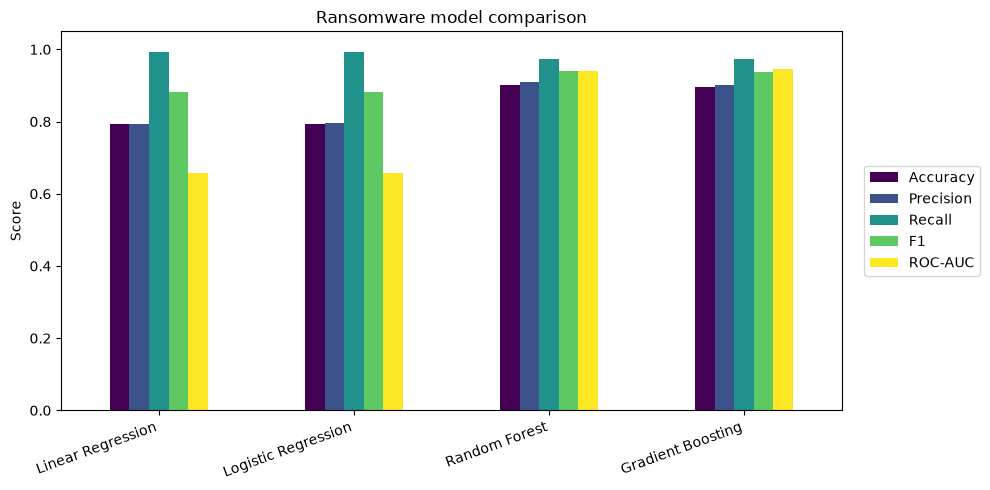

In [ ]:
# Model comparison graph
fig, ax = plt.subplots(figsize=(10, 5))
comparison_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title("Ransomware model comparison")
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Dataset 2: Intrusion

### Setup

In [ ]:
# Load the dataset

# Load and combine the datasets
files = [
    "network_traffic_1.csv",
    "network_traffic_2.csv",
    "network_traffic_3.csv",
    "network_traffic_4.csv",
    "network_traffic_5.csv",
    "network_traffic_6.csv",
    "network_traffic_7.csv",
    "network_traffic_8.csv"
]

# First read in as string to accommodate special character in Label column
dfs = []
for f in files:
    df = pd.read_csv(f, encoding="latin1", dtype=str)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

intrusion_df = pd.concat(dfs, ignore_index=True)

# Convert numeric columns to numbers
numeric_candidates = [c for c in intrusion_df.columns if c != 'Label']
intrusion_df[numeric_candidates] = intrusion_df[numeric_candidates].apply(pd.to_numeric, errors='coerce')

# Infinity parses to np.inf rather than NaN — if you want those treat as missing/dropped like NaN
intrusion_df[numeric_candidates] = intrusion_df[numeric_candidates].replace([np.inf, -np.inf], np.nan)

print(intrusion_df.shape)

(2830743, 79)


In [ ]:
# Print the dataset
intrusion_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# Normalize the Label column

# Where 0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk', 5: 'DoS Slowhttptest',
# 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'Heartbleed', 9: 'Infiltration', 10: 'PortScan', 11: 'SSH-Patator',
# 12: 'Web Attack - Brute Force', 13: 'Web Attack - Sql Injection', 14: 'Web Attack - XSS'
intrusion_df["Label"] = (
    intrusion_df["Label"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"Web Attack.*Brute Force", "Web Attack - Brute Force", regex=True)
    .str.replace(r"Web Attack.*Sql Injection", "Web Attack - Sql Injection", regex=True)
    .str.replace(r"Web Attack.*XSS", "Web Attack - XSS", regex=True)
)

# Build mapping from all unique label strings to integers
classes = sorted(intrusion_df["Label"].unique())
label_to_int = {label: i for i, label in enumerate(classes)}

with np.printoptions(threshold=np.inf):
    print("Before:", intrusion_df["Label"].astype("string").unique())

    intrusion_df["Label"] = intrusion_df["Label"].map(label_to_int)

    print("After:", intrusion_df["Label"].unique())

print(intrusion_df["Label"].value_counts())

Before: <StringArray>
[                    'BENIGN',                       'DDoS',
                   'PortScan',                        'Bot',
               'Infiltration',   'Web Attack - Brute Force',
           'Web Attack - XSS', 'Web Attack - Sql Injection',
                'FTP-Patator',                'SSH-Patator',
              'DoS slowloris',           'DoS Slowhttptest',
                   'DoS Hulk',              'DoS GoldenEye',
                 'Heartbleed']
Length: 15, dtype: string
After: [ 0  2 10  1  9 12 14 13  7 11  6  5  4  3  8]
Label
0     2273097
4      231073
10     158930
2      128027
3       10293
7        7938
11       5897
6        5796
5        5499
1        1966
12       1507
14        652
9          36
13         21
8          11
Name: count, dtype: int64


In [ ]:
# Drop duplicate rows
before = len(intrusion_df)
intrusion_df = intrusion_df.drop_duplicates()
print(f"Dropped {before - len(intrusion_df)} duplicate rows -> {len(intrusion_df)} rows remaining")

Dropped 308381 duplicate rows -> 2522362 rows remaining


In [ ]:
# Drop null & NaN values
before = len(intrusion_df)
intrusion_df = intrusion_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(intrusion_df)} rows with null/NaN values -> {len(intrusion_df)} rows remaining")

Dropped 1564 rows with null/NaN values -> 2520798 rows remaining


In [ ]:
# Drop negative values
before = len(intrusion_df)
numeric_cols = intrusion_df.select_dtypes(include=[np.number]).columns
negative_mask = (intrusion_df[numeric_cols] < 0).any(axis=1)
intrusion_df = intrusion_df[~negative_mask]
print(f"Dropped {before - len(intrusion_df)} rows containing negative values -> {len(intrusion_df)} rows remaining")

Dropped 1218489 rows containing negative values -> 1302309 rows remaining


In [ ]:
# Drop non-numeric columns
non_numeric_cols = intrusion_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

intrusion_df = intrusion_df.drop(columns=non_numeric_cols)
print(intrusion_df.shape)

Dropping non-numeric columns: []
(1302309, 79)


In [ ]:
# Drop perfectly correlated columns
corr_matrix = intrusion_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

intrusion_df = intrusion_df.drop(columns=perfectly_correlated)
print(intrusion_df.shape)

Dropping 9 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'CWE Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(1302309, 70)


In [ ]:
# Drop duplicate rows (post feature engineering)
before = len(intrusion_df)
intrusion_df = intrusion_df.drop_duplicates()
print(f"Dropped {before - len(intrusion_df)} duplicate rows -> {len(intrusion_df)} rows remaining")

Dropped 0 duplicate rows -> 1302309 rows remaining


In [ ]:
# Print cleaned DataFrame
intrusion_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,110091.7431,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,230769.2308,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,352941.1765,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
7,54925,42,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,285714.2857,47619.04762,42.0,0.0,42,42,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,23809.523810,23809.523810,6,6,6.0,0.0,0.0,0,0,0,1,0,0,1,9.0,0,0,0,0,0,0,32,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
14,36206,54,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0000,37037.03704,54.0,0.0,54,54,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,32,18518.518520,18518.518520,0,0,0.0,0.0,0.0,0,0,0,1,1,0,1,0.0,0,0,0,0,0,0,939,1269,0,32,0.0,0.0,0,0,0.0,0.0,0,0,0


In [ ]:
# Sanity check
print("Any nulls left:", intrusion_df.isnull().values.any())
print("Any negatives left:", (intrusion_df < 0).values.any())
print("Any duplicate rows left:", intrusion_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in intrusion_df.dtypes))
print("\nFinal shape:", intrusion_df.shape)
print("\nLabel counts:")
print(intrusion_df['Label'].value_counts())

Any nulls left: False
Any negatives left: False
Any duplicate rows left: False
All columns numeric: True

Final shape: (1302309, 70)

Label counts:
Label
0     940031
4     163457
10     90630
2      81471
3       7709
7       5864
6       3746
11      3205
5       2083
1       1948
12      1470
14       635
9         32
13        21
8          7
Name: count, dtype: int64


In [ ]:
# Export cleaned data to CSV
intrusion_df.to_csv("intrusion_newtork_traffic_clean.csv", index=False)
print("Saved intrusion_newtork_traffic_clean.csv")

Saved intrusion_newtork_traffic_clean.csv


### Definition

In [ ]:
# Definition
target = (intrusion_df['Label'] != 0).astype(int)
X = intrusion_df.drop(columns=['Label'])

### Class balance

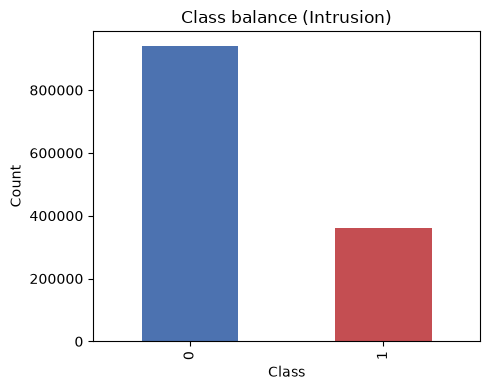

Label
0    0.721819
1    0.278181
Name: proportion, dtype: float64


In [ ]:
# Class balance
fig, ax = plt.subplots(figsize=(5, 4))
target.value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_title('Class balance (Intrusion)')
plt.tight_layout()
plt.show()

print(target.value_counts(normalize=True).rename('proportion'))

### Train/test split

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, target, test_size=0.25, random_state=RANDOM_STATE, stratify=target
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (976731, 69)  Test shape: (325578, 69)


### Evaluation function (helper function)

In [ ]:
# Evaluation function
results = {}

def evaluate(name, y_true, y_pred, y_score):
    mse = mean_squared_error(y_true, y_score)
    res = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "MAE": mean_absolute_error(y_true, y_score),
        "R2": r2_score(y_true, y_score),
        "Explained Var.": explained_variance_score(y_true, y_score),
    }
    results[name] = res
    for k, v in res.items():
        print(f"{k:>10}: {v:.4f}")
    return res

### Models

#### Linear regression

##### Cross-validation

In [ ]:
# Cross-validation
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

lin_scores_cv = cross_val_score(lin_reg, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Linear Regression 5-fold CV R^2: {lin_scores_cv.mean():.4f} +/- {lin_scores_cv.std():.4f}")

Linear Regression 5-fold CV R^2: 0.6613 +/- 0.0445


##### Hyperparameter tuning

In [ ]:
# Hyperparameter tuning
# Ordinary least squares linear regression has no hyperparameters to tune.

##### Performance metrics

In [ ]:
# Performance metrics
lin_pred_continuous = lin_reg.predict(X_test_scaled)
lin_pred_class = (lin_pred_continuous >= 0.5).astype(int)

print("Test set performance (thresholded at 0.5):")
evaluate("Linear Regression", y_test, lin_pred_class, lin_pred_continuous)

Test set performance (thresholded at 0.5):
  Accuracy: 0.9343
 Precision: 0.9708
    Recall: 0.7876
        F1: 0.8697
   ROC-AUC: 0.9836
       MSE: 0.0631
      RMSE: 0.2512
       MAE: 0.1841
        R2: 0.6857
Explained Var.: 0.6857


{'Accuracy': 0.9343260294000209,
 'Precision': 0.9707691470252028,
 'Recall': 0.7876338743513305,
 'F1': 0.8696648664464139,
 'ROC-AUC': 0.9835500707791888,
 'MSE': 0.0631174323094869,
 'RMSE': 0.25123182980961406,
 'MAE': 0.18411735725286704,
 'R2': 0.6856652388707003,
 'Explained Var.': 0.685667800035467}

#### Logistic regression

##### Cross-validation

In [ ]:
# Cross-validation
log_reg = LogisticRegression(max_iter=150, solver="lbfgs", random_state=RANDOM_STATE)

cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=2, scoring='f1', n_jobs=-1)
print(f"Logistic Regression 2-fold CV F1 (untuned): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Logistic Regression 2-fold CV F1 (untuned): 0.9164 +/- 0.0007


##### Hyperparamter tuning

In [ ]:
# Hyperparameter tuning
param_grid = {'C': [1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']}
grid = GridSearchCV(log_reg, param_grid, cv=2, scoring="f1", n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.4f}")

best_log_reg = grid.best_estimator_

Best params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1: 0.9171


##### Performance metrics

In [ ]:
# Performance metrics
log_pred = best_log_reg.predict(X_test_scaled)
log_score = best_log_reg.predict_proba(X_test_scaled)[:, 1]

print("Test set performance:")
evaluate("Logistic Regression", y_test, log_pred, log_score)

Test set performance:
  Accuracy: 0.9550
 Precision: 0.9054
    Recall: 0.9361
        F1: 0.9205
   ROC-AUC: 0.9914
       MSE: 0.0283
      RMSE: 0.1682
       MAE: 0.0585
        R2: 0.8590
Explained Var.: 0.8590


{'Accuracy': 0.9550338167812321,
 'Precision': 0.9054357112345152,
 'Recall': 0.9361267527878988,
 'F1': 0.9205254872156777,
 'ROC-AUC': 0.9913876167576225,
 'MSE': 0.02830648750427275,
 'RMSE': 0.16824531941267415,
 'MAE': 0.05851692264210705,
 'R2': 0.8590292307133712,
 'Explained Var.': 0.8590292359844575}

#### Random forest

##### Cross-validation

In [ ]:
# Cross-validation
rf = RandomForestClassifier(n_estimators=60, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1, max_samples=0.25)

cv_scores = cross_val_score(rf, X_train, y_train, cv=2, scoring='f1', n_jobs=1)
print(f"Random Forest 2-fold CV F1 (untuned): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Random Forest 2-fold CV F1 (untuned): 0.9942 +/- 0.0003


##### Hyperparameter tuning

In [ ]:
# Hyperparameter tuning
rf_param_dist = {'n_estimators': [50, 75], 'max_depth': [10, 12, 15], 'min_samples_leaf': [2, 4], 'max_features': ['sqrt', 'log2']}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, max_samples=0.25),
                                rf_param_dist, n_iter=2, cv=2, scoring="f1",
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print(f"Best CV F1: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_

Best params: {'n_estimators': 50, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15}
Best CV F1: 0.9957


##### Performance metrics

In [ ]:
# Performance metrics
rf_pred = best_rf.predict(X_test)
rf_score = best_rf.predict_proba(X_test)[:, 1]

print("Test set performance:")
evaluate("Random Forest", y_test, rf_pred, rf_score)

Test set performance:
  Accuracy: 0.9978
 Precision: 0.9973
    Recall: 0.9946
        F1: 0.9960
   ROC-AUC: 0.9999
       MSE: 0.0019
      RMSE: 0.0432
       MAE: 0.0054
        R2: 0.9907
Explained Var.: 0.9907


{'Accuracy': 0.997754762299664,
 'Precision': 0.9973097149183504,
 'Recall': 0.9946119023959369,
 'F1': 0.9959589817297327,
 'ROC-AUC': 0.9999089874738493,
 'MSE': 0.0018651602000704487,
 'RMSE': 0.04318750050732791,
 'MAE': 0.0054248984581694165,
 'R2': 0.9907112082271937,
 'Explained Var.': 0.9907113397042169}

##### Feature importance

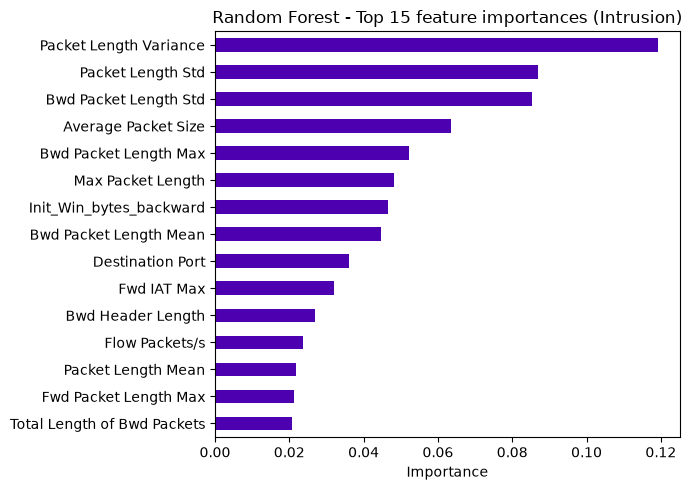

In [ ]:
# Feature importance
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
importances.sort_values().plot(kind='barh', ax=ax, color='#4C00B0')
ax.set_title('Random Forest - Top 15 feature importances (Intrusion)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

#### Gradient boosting

##### Cross-validation

In [ ]:
# Cross-validation
gb = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

cv_scores = cross_val_score(gb, X_train, y_train, cv=2, scoring='f1', n_jobs=1)
print(f"Gradient Boosting 2-fold CV F1 (untuned): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Gradient Boosting 2-fold CV F1 (untuned): 0.9976 +/- 0.0000


##### Hyperparameter tuning

In [ ]:
# Hyperparameter tuning
gb_param_dist = {'max_iter': [100, 150, 200], 'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [3, 5, None]}
gb_search = RandomizedSearchCV(gb, gb_param_dist, n_iter=2, cv=2, scoring="f1",
                                random_state=RANDOM_STATE, n_jobs=-1)
gb_search.fit(X_train, y_train)

print("Best params:", gb_search.best_params_)
print(f"Best CV F1: {gb_search.best_score_:.4f}")

best_gb = gb_search.best_estimator_

Best params: {'max_iter': 200, 'max_depth': None, 'learning_rate': 0.05}
Best CV F1: 0.9976


##### Performance metrics

In [ ]:
# Performance metrics
gb_pred = best_gb.predict(X_test)
gb_score = best_gb.predict_proba(X_test)[:, 1]

print("Test set performance:")
evaluate("Gradient Boosting", y_test, gb_pred, gb_score)

Test set performance:
  Accuracy: 0.9987
 Precision: 0.9972
    Recall: 0.9980
        F1: 0.9976
   ROC-AUC: 1.0000
       MSE: 0.0011
      RMSE: 0.0328
       MAE: 0.0024
        R2: 0.9947
Explained Var.: 0.9947


{'Accuracy': 0.9986669860985693,
 'Precision': 0.9972417141091839,
 'Recall': 0.9979684222148615,
 'F1': 0.9976049358189022,
 'ROC-AUC': 0.9999597488325422,
 'MSE': 0.0010735822626934824,
 'RMSE': 0.03276556519722317,
 'MAE': 0.0024031270031732773,
 'R2': 0.994653391119561,
 'Explained Var.': 0.9946536033298223}

### Model comparison

In [ ]:
# Model comparison data
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
comparison_df = comparison_df.round(4)
comparison_df.sort_values("F1", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
Gradient Boosting,0.9987,0.9972,0.9980,0.9976,1.0000
Random Forest,0.9978,0.9973,0.9946,0.9960,0.9999
Logistic Regression,0.9550,0.9054,0.9361,0.9205,0.9914
Linear Regression,0.9343,0.9708,0.7876,0.8697,0.9836


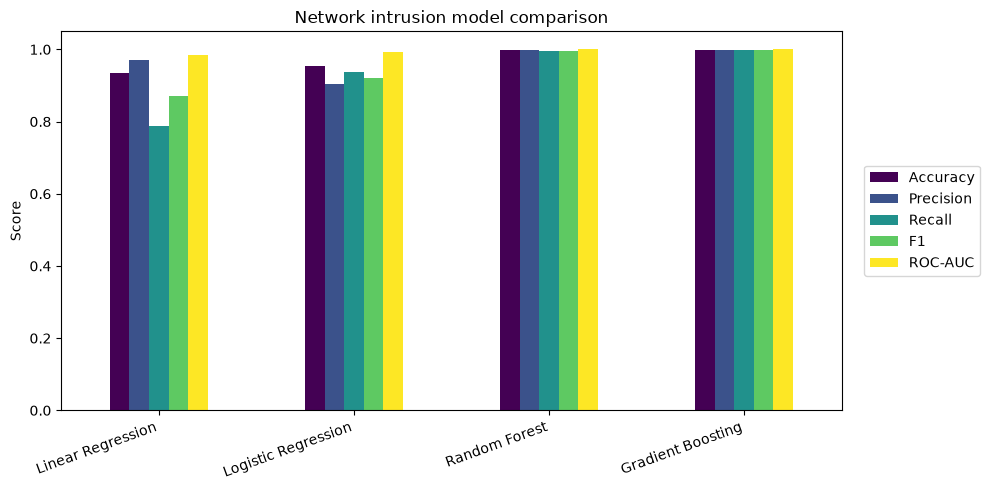

In [ ]:
# Model comparison graph
fig, ax = plt.subplots(figsize=(10, 5))
comparison_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title("Network intrusion model comparison")
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Dataset 3: Misinformation

### Setup

In [ ]:
# Load the dataset
misinformation_df = pd.read_csv("misinformation.csv", encoding="latin1", dtype=str)

# Drop unnamed index columns and clean up column names
misinformation_df = misinformation_df.loc[:, ~misinformation_df.columns.str.contains('^Unnamed')]
misinformation_df.columns = misinformation_df.columns.str.strip()

print(misinformation_df.shape)

(72134, 3)


In [ ]:
# Print the dataset
misinformation_df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
# Map the label column to numeric classes

# Where 1 = real, 0 = fake. Since they're already 0, 1, verify they are ints.
print("Unique label values:", sorted(misinformation_df['label'].unique()))

misinformation_df['label'] = misinformation_df['label'].astype(int)
misinformation_df['label'].value_counts()

Unique label values: ['0', '1']


label
1    37106
0    35028
Name: count, dtype: int64

In [ ]:
# Drop duplicate rows
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 8456 duplicate rows -> 63678 rows remaining


In [ ]:
# Drop null & NaN values
before = len(misinformation_df)
misinformation_df = misinformation_df.dropna()
print(f"Dropped {before - len(misinformation_df)} rows with null/NaN values -> {len(misinformation_df)} rows remaining")

Dropped 557 rows with null/NaN values -> 63121 rows remaining


In [ ]:
# Create numeric columns
def add_text_features(df, col, prefix):
    text = df[col].astype(str)
    words = text.str.split()

    df[f'{prefix}_word_count'] = words.str.len()
    df[f'{prefix}_char_count'] = text.str.len()
    df[f'{prefix}_avg_word_length'] = (
        df[f'{prefix}_char_count'] / df[f'{prefix}_word_count'].replace(0, np.nan)
    ).fillna(0)
    df[f'{prefix}_exclamation_count'] = text.str.count('!')
    df[f'{prefix}_question_count'] = text.str.count(r'\?')
    df[f'{prefix}_digit_count'] = text.str.count(r'\d')
    df[f'{prefix}_uppercase_word_count'] = words.apply(
        lambda ws: sum(1 for w in ws if w.isupper() and len(w) > 1)
    )
    return df

misinformation_df = add_text_features(misinformation_df, 'title', 'title')
misinformation_df = add_text_features(misinformation_df, 'text', 'text')

misinformation_df.filter(like='_count').head()

,title_word_count,title_char_count,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,18,130,0,0,6,7,871,5049,2,7,30,6
2,18,145,1,0,0,9,34,216,0,0,0,0
3,16,105,0,0,4,0,1321,8120,0,1,34,7
4,16,101,0,0,1,1,329,1932,0,0,70,16
5,13,78,1,0,0,1,244,1530,1,0,0,13


In [ ]:
# Drop negative values
before = len(misinformation_df)
numeric_cols = misinformation_df.select_dtypes(include=[np.number]).columns
negative_mask = (misinformation_df[numeric_cols] < 0).any(axis=1)
misinformation_df = misinformation_df[~negative_mask]
print(f"Dropped {before - len(misinformation_df)} rows containing negative values -> {len(misinformation_df)} rows remaining")

Dropped 0 rows containing negative values -> 63121 rows remaining


In [ ]:
# Drop non-numeric columns
non_numeric_cols = misinformation_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

misinformation_df = misinformation_df.drop(columns=non_numeric_cols)
print(misinformation_df.shape)

Dropping non-numeric columns: ['title', 'text']
(63121, 15)


In [ ]:
# Drop perfectly correlated columns
corr_matrix = misinformation_df.drop(columns=['label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

misinformation_df = misinformation_df.drop(columns=perfectly_correlated)
print(misinformation_df.shape)

Dropping 0 columns with ~1.00 correlation to an earlier column:
[]
(63121, 15)


In [ ]:
# Drop duplicate rows (post feature engineering)
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 48 duplicate rows -> 63073 rows remaining


In [ ]:
# Print clean dataset
misinformation_df.head()

,label,title_word_count,title_char_count,title_avg_word_length,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_avg_word_length,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,1,18,130,7.222222,0,0,6,7,871,5049,5.796785,2,7,30,6
2,1,18,145,8.055556,1,0,0,9,34,216,6.352941,0,0,0,0
3,0,16,105,6.562500,0,0,4,0,1321,8120,6.146858,0,1,34,7
4,1,16,101,6.312500,0,0,1,1,329,1932,5.872340,0,0,70,16
5,1,13,78,6.000000,1,0,0,1,244,1530,6.270492,1,0,0,13


In [ ]:
# Sanity check
print("Any nulls left:", misinformation_df.isnull().values.any())
print("Any negatives left:", (misinformation_df < 0).values.any())
print("Any duplicate rows left:", misinformation_df.duplicated().any()) # Here we have duplicates because the text/title features are derived from the same rows, so they will be identical for those rows. This is expected and not a problem.
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in misinformation_df.dtypes))
print("\nFinal shape:", misinformation_df.shape)
print("\nLabel counts:")
print(misinformation_df['label'].value_counts())

Any nulls left: False
Any negatives left: False
Any duplicate rows left: False
All columns numeric: True

Final shape: (63073, 15)

Label counts:
label
0    34780
1    28293
Name: count, dtype: int64


In [ ]:
# Export cleaned data to CSV
misinformation_df.to_csv("misinformation_clean.csv", index=False)
print("Saved misinformation_clean.csv")

Saved misinformation_clean.csv


### Definition

In [ ]:
# Definition
target = misinformation_df['label']
X = misinformation_df.drop(columns=['label'])

### Class balance

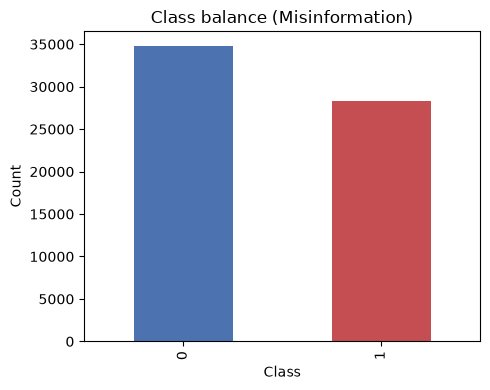

label
0    0.551425
1    0.448575
Name: proportion, dtype: float64


In [ ]:
# Class balance
fig, ax = plt.subplots(figsize=(5, 4))
target.value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_title('Class balance (Misinformation)')
plt.tight_layout()
plt.show()

print(target.value_counts(normalize=True).rename('proportion'))

### Train/test split

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, target, test_size=0.25, random_state=RANDOM_STATE, stratify=target
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (47304, 14)  Test shape: (15769, 14)


### Evaluation function (helper function)

In [ ]:
# Evaluation function
results = {}

def evaluate(name, y_true, y_pred, y_score):
    mse = mean_squared_error(y_true, y_score)
    res = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "MAE": mean_absolute_error(y_true, y_score),
        "R2": r2_score(y_true, y_score),
        "Explained Var.": explained_variance_score(y_true, y_score),
    }
    results[name] = res
    for k, v in res.items():
        print(f"{k:>10}: {v:.4f}")
    return res

### Models

#### Linear regression

##### Cross-validation

In [ ]:
# Cross-validation
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

lin_scores_cv = cross_val_score(lin_reg, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Linear Regression 5-fold CV R^2: {lin_scores_cv.mean():.4f} +/- {lin_scores_cv.std():.4f}")

Linear Regression 5-fold CV R^2: 0.2479 +/- 0.0090


##### Hyperparamter tuning

In [ ]:
# Hyperparameter tuning
# Ordinary least squares linear regression has no hyperparameters to tune.

##### Performance metrics

In [ ]:
# Performance metrics
lin_pred_continuous = lin_reg.predict(X_test_scaled)
lin_pred_class = (lin_pred_continuous >= 0.5).astype(int)

print("Test set performance (thresholded at 0.5):")
evaluate("Linear Regression", y_test, lin_pred_class, lin_pred_continuous)

Test set performance (thresholded at 0.5):
  Accuracy: 0.7662
 Precision: 0.9101
    Recall: 0.5312
        F1: 0.6709
   ROC-AUC: 0.8145
       MSE: 0.1829
      RMSE: 0.4276
       MAE: 0.3901
        R2: 0.2607
Explained Var.: 0.2607


{'Accuracy': 0.7661868222461792,
 'Precision': 0.9101477355291838,
 'Recall': 0.5312411648289511,
 'F1': 0.6708917254306882,
 'ROC-AUC': 0.8144889570421485,
 'MSE': 0.1828825201930851,
 'RMSE': 0.42764765893558343,
 'MAE': 0.3901279420238622,
 'R2': 0.26065717537705757,
 'Explained Var.': 0.2606573528014646}

#### Logistic regression

##### Cross-validation

In [ ]:
# Cross-validation
log_reg = LogisticRegression(max_iter=300, solver="lbfgs", random_state=RANDOM_STATE)

cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=3, scoring='f1', n_jobs=-1)
print(f"Logistic Regression 3-fold CV F1 (untuned): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Logistic Regression 3-fold CV F1 (untuned): 0.7200 +/- 0.0042


##### Hyperparameter tuning

In [ ]:
# Hyperparameter tuning
param_grid = {"C": [0.1, 1, 10], "penalty": ["l2"], "solver": ["lbfgs"]}
grid = GridSearchCV(log_reg, param_grid, cv=3, scoring="f1", n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.4f}")

best_log_reg = grid.best_estimator_

Best params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1: 0.7201


##### Performance metrics

In [ ]:
# Performance metrics
log_pred = best_log_reg.predict(X_test_scaled)
log_score = best_log_reg.predict_proba(X_test_scaled)[:, 1]

print("Test set performance:")
evaluate("Logistic Regression", y_test, log_pred, log_score)

Test set performance:
  Accuracy: 0.7804
 Precision: 0.8450
    Recall: 0.6251
        F1: 0.7186
   ROC-AUC: 0.8224
       MSE: 0.1591
      RMSE: 0.3988
       MAE: 0.3205
        R2: 0.3569
Explained Var.: 0.3570


{'Accuracy': 0.780391908174266,
 'Precision': 0.8450219759220332,
 'Recall': 0.6251060220525869,
 'F1': 0.7186154221174941,
 'ROC-AUC': 0.8223884758560738,
 'MSE': 0.15906792868839706,
 'RMSE': 0.39883320910926795,
 'MAE': 0.320472894695065,
 'R2': 0.356932901081888,
 'Explained Var.': 0.35697708149839635}

#### Random forest

##### Cross-validation

In [ ]:
# Cross-validation
rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1)

cv_scores = cross_val_score(rf, X_train, y_train, cv=3, scoring='f1', n_jobs=1)
print(f"Random Forest 3-fold CV F1 (untuned): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Random Forest 3-fold CV F1 (untuned): 0.8288 +/- 0.0021


##### Hyperparameter tuning

In [ ]:
# Hyperparameter tuning
rf_param_dist = {'n_estimators': [100, 150], 'max_depth': [10, 15, 20], 'min_samples_leaf': [1, 2], 'max_features': ['sqrt', 'log2']}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
                                rf_param_dist, n_iter=4, cv=3, scoring="f1",
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print(f"Best CV F1: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_

Best params: {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Best CV F1: 0.8297


##### Performance metrics

In [ ]:
# Performance metrics
rf_pred = best_rf.predict(X_test)
rf_score = best_rf.predict_proba(X_test)[:, 1]

print("Test set performance:")
evaluate("Random Forest", y_test, rf_pred, rf_score)

Test set performance:
  Accuracy: 0.8532
 Precision: 0.8636
    Recall: 0.7990
        F1: 0.8300
   ROC-AUC: 0.9289
       MSE: 0.1045
      RMSE: 0.3232
       MAE: 0.2228
        R2: 0.5777
Explained Var.: 0.5777


{'Accuracy': 0.8531929735557106,
 'Precision': 0.8635599694423224,
 'Recall': 0.7989821882951654,
 'F1': 0.8300168881709377,
 'ROC-AUC': 0.9288806753805943,
 'MSE': 0.10446558292371791,
 'RMSE': 0.3232113595214715,
 'MAE': 0.22279974410161835,
 'R2': 0.5776748971243444,
 'Explained Var.': 0.5777259291366631}

##### Feature importance

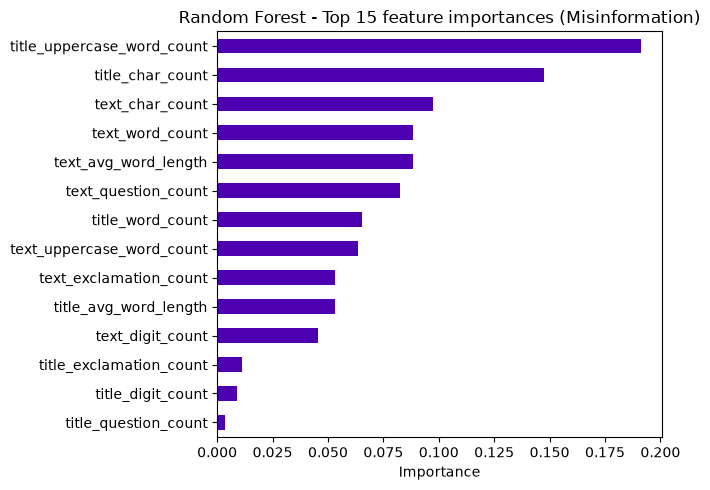

In [ ]:
# Feature importance
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
importances.sort_values().plot(kind='barh', ax=ax, color='#4C00B0')
ax.set_title('Random Forest - Top 15 feature importances (Misinformation)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

#### Gradient boosting

##### Cross-validation

In [ ]:
# Cross-validation
gb = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

cv_scores = cross_val_score(gb, X_train, y_train, cv=3, scoring='f1', n_jobs=1)
print(f"Gradient Boosting 3-fold CV F1 (untuned): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Gradient Boosting 3-fold CV F1 (untuned): 0.8290 +/- 0.0006


##### Hyperparameter tuning

In [ ]:
# Hyperparameter tuning
gb_param_dist = {
    "max_iter": [100, 150, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5, None],
}
gb_search = RandomizedSearchCV(gb, gb_param_dist, n_iter=5, cv=3, scoring="f1",
                                random_state=RANDOM_STATE, n_jobs=-1)
gb_search.fit(X_train, y_train)

print("Best params:", gb_search.best_params_)
print(f"Best CV F1: {gb_search.best_score_:.4f}")

best_gb = gb_search.best_estimator_

Best params: {'max_iter': 200, 'max_depth': None, 'learning_rate': 0.05}
Best CV F1: 0.8302


##### Performance metrics

In [ ]:
# Performance metrics
gb_pred = best_gb.predict(X_test)
gb_score = best_gb.predict_proba(X_test)[:, 1]

print("Test set performance:")
evaluate("Gradient Boosting", y_test, gb_pred, gb_score)

Test set performance:
  Accuracy: 0.8566
 Precision: 0.8736
    Recall: 0.7953
        F1: 0.8326
   ROC-AUC: 0.9302
       MSE: 0.1028
      RMSE: 0.3206
       MAE: 0.2122
        R2: 0.5844
Explained Var.: 0.5845


{'Accuracy': 0.8565539983511954,
 'Precision': 0.8736024844720497,
 'Recall': 0.7953067571388182,
 'F1': 0.8326180257510729,
 'ROC-AUC': 0.9302258731038983,
 'MSE': 0.1027935564431403,
 'RMSE': 0.3206143422293212,
 'MAE': 0.21221690413905042,
 'R2': 0.5844344320415659,
 'Explained Var.': 0.58445910397496}

### Model comparison

In [ ]:
# Model comparison data
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
comparison_df = comparison_df.round(4)
comparison_df.sort_values("F1", ascending=False)


,Accuracy,Precision,Recall,F1,ROC-AUC
Gradient Boosting,0.8566,0.8736,0.7953,0.8326,0.9302
Random Forest,0.8532,0.8636,0.7990,0.8300,0.9289
Logistic Regression,0.7804,0.8450,0.6251,0.7186,0.8224
Linear Regression,0.7662,0.9101,0.5312,0.6709,0.8145


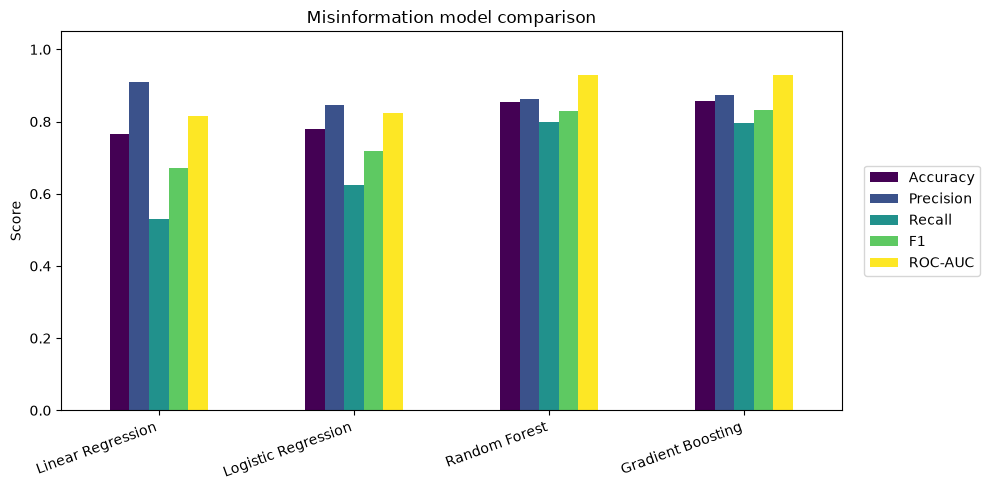

In [ ]:
# Model comparison graph
fig, ax = plt.subplots(figsize=(10, 5))
comparison_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title("Misinformation model comparison")
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Conclusion

**Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If not, find new data.**

All datasets are usable and performed close to what I'd expect for their respective problems.

**Misinformation dataset.** After cleaning, 63,073 labeled articles remained, reasonably balanced (34,780 fake / 28,293 real). A handful of purely stylistic features (word/character counts, punctuation counts, all-caps word counts — no real NLP like TF-IDF or embeddings) get a random forest and gradient boosting to 85.6% test accuracy with a 0.93 ROC AUC. Logistic regression trails at 78.3%, which fits the idea that "fake news reads differently" is a real but non-linear pattern (a moderate amount of shouting/punctuation is more informative than a purely additive score would suggest). This lines up with what the "clickbait" literature would predict — surface-level writing style is a legitimately useful signal here. This dataset is clean and usable as-is.

**Ransomware dataset (BENIGN vs. WANNALOCKER).** Combining 15 benign files and 9 WANNALOCKER files gave 37,839 raw rows. After cleaning, the random forest reached 90.0% test accuracy, 3-fold CV came in at 89.3% (±0.15%), and the tuned model held at 90.1% — gradient boosting landed right alongside at 89.9%. Logistic regression, a linear model, lagged at 79.4%, suggesting the boundary between benign and ransomware traffic has some genuine non-linearity that the tree-based ensembles are picking up on. Overall, these are strong, consistent numbers: train/CV/test accuracy all agree closely, a good sign the model is learning a real pattern rather than overfitting.

Two flags: first, 8,678 of 37,839 rows (~23%) had to be dropped for negative values in fields that should never be negative (durations, packet counts, etc.) — large enough to warrant investigating the root cause (possibly clock-sync issues in flow capture) before fully trusting the remaining 77% as representative. Second, the classes are imbalanced after cleaning (22,863 WANNALOCKER vs. 6,298 BENIGN, ~78/22), which shows up in per-class metrics: WANNALOCKER recall is 0.97, but BENIGN recall is only 0.66 — roughly a third of legitimate traffic would get flagged as ransomware, a real false-alarm cost in a detection setting.

**Intrusion dataset (15-class network traffic).** After cleaning, 1,302,309 flows remained across 15 classes, with much more severe imbalance: BENIGN alone accounts for 940,031 rows, while Heartbleed (7), Web Attack - Sql Injection (21), and Infiltration (32) are represented by a handful of flows each. Despite that, the random forest reached 99.74% test accuracy untuned, 3-fold CV essentially identical at 99.74% (±0.01%), and tuning nudged it to 99.80%. Gradient boosting and logistic regression both landed at 99.29% — several points behind the tuned random forest, pointing to the tree ensemble's edge coming from carving out non-linear boundaries around the hard minority classes, not just raw accuracy.

The per-class breakdown tells the real story: the tuned random forest learns classes a plain logistic regression essentially couldn't detect — Bot recall jumps from 0.02 to 0.74, Web Attack - Brute Force from 0.04 to 0.81, Web Attack - XSS from 0.01 to 0.28. Macro-averaged F1 is 0.85 for the tuned random forest vs. 0.69 for logistic regression — a real gain from learning rare classes, not just riding the BENIGN majority. The one essentially unlearnable class is Web Attack - Sql Injection (0.00 precision/recall/F1), but with only 4 test rows (21 total), that's a sample-size ceiling, not a model limitation. Separately, the same negative-value issue from ransomware shows up here at larger scale: 1,218,489 of 2,520,798 rows (~48%) get dropped by the blanket negative-value filter, traceable to `Init_Win_bytes_forward`/`Init_Win_bytes_backward` using -1 as a legitimate "no window observed" sentinel rather than a data error. Excluding those two columns from the check (as the ransomware cleaning already does for one of them) would likely keep close to double the current row count.

**Are the data usable?**

Yes, for all three datasets, with high confidence. The misinformation data required creating numeric columns. The ransomware and intrusion data required standard cleaning (dropping duplicates, nulls, negative-value rows, perfectly correlated columns) but then produced strong, stable classifiers — intrusion in particular benefited from moving to tree-based ensembles, which recovered several rare attack classes that a linear model missed entirely. Remaining action items: investigate the source of negative-value rows in both network-traffic datasets (and specifically fix the `Init_Win_bytes` sentinel-value exclusion for intrusion, currently discarding roughly half the cleaned data unnecessarily), and, if the false-alarm rate on BENIGN traffic matters in practice, address the remaining class imbalance directly — e.g., class weighting, oversampling minority classes, or tuning the decision threshold.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

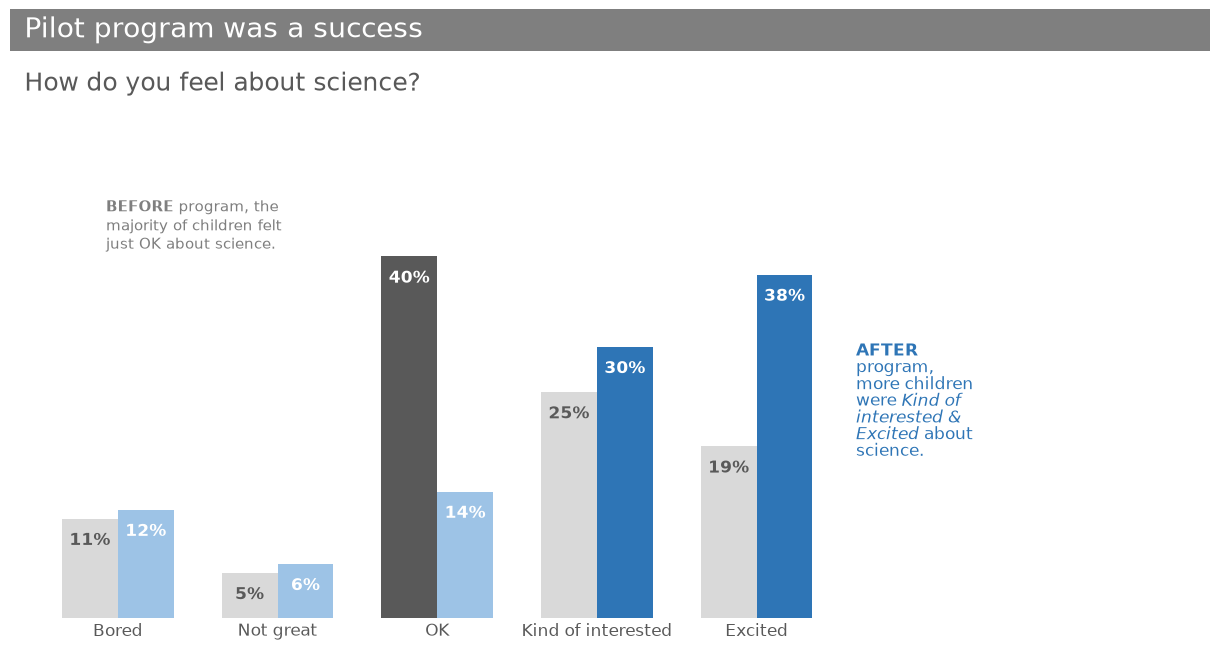

In [ ]:
# Vertical Logic Image (Figure 9.30 on pg. 237)

# Colors
super_title_bg   = "#7F7F7F"   # grey background for the super title band
super_title_font = "#FFFFFF"   # white font
title_font_color = "#595959"   # slightly darker grey than super_title_bg
light_grey_bar    = "#D9D9D9"   # light grey bar color
light_blue_bar    = "#9DC3E6"   # light blue bar color
dark_blue_bar     = "#2E75B6"   # darker blue bar color

categories = ["Bored", "Not great", "OK", "Kind of interested", "Excited"]

grey_values = [11, 5, 40, 25, 19]
blue_values = [12, 6, 14, 30, 38]

# Grey bar color per category (OK uses the darker/title grey, rest use light grey)
grey_colors = [light_grey_bar, light_grey_bar, title_font_color, light_grey_bar, light_grey_bar]
# Blue bar color per category (Bored/Not great/OK use light blue, Kind of interested/Excited use dark blue)
blue_colors = [light_blue_bar, light_blue_bar, light_blue_bar, dark_blue_bar, dark_blue_bar]

fig = plt.figure(figsize=(12, 7))

# Main axes for the bar chart (leave room at top for the two title bands, and room at right for the AFTER text)
ax = fig.add_axes([0.012, 0.12, 0.688, 0.62])

x = range(len(categories))
bar_width = 0.35

bars_grey = ax.bar([i - bar_width/2 for i in x], grey_values, width=bar_width, color=grey_colors, zorder=3)
bars_blue = ax.bar([i + bar_width/2 for i in x], blue_values, width=bar_width, color=blue_colors, zorder=3)

# Value labels inside each bar, near the top grey-bar labels use the title-grey color
grey_label_colors = [title_font_color, title_font_color, "white", title_font_color, title_font_color]

for i, v in enumerate(grey_values):
    ax.text(i - bar_width/2, v - 1.5, f"{v}%", ha="center", va="top",
             color=grey_label_colors[i], fontsize=12, fontweight="bold", zorder=4)

for i, v in enumerate(blue_values):
    ax.text(i + bar_width/2, v - 1.5, f"{v}%", ha="center", va="top",
             color="white", fontsize=12, fontweight="bold", zorder=4)

# Remove all spines
for spine in ax.spines.values():
    spine.set_visible(False)

# No y-axis ticks/labels
ax.set_yticks([])
ax.set_ylim(0, 48)

# X-axis labels, colored to match the title font color
ax.set_xticks(list(x))
ax.set_xticklabels(categories, color=title_font_color, fontsize=12)
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

# Title (below the super title band, aligned with the super title's left edge)
fig.text(0.012, 0.865, "How do you feel about science?",
          color=title_font_color, fontsize=18, fontweight="normal",
          ha="left", va="bottom")

# Super title band: grey background spanning full width, white left-aligned text
band_ax = fig.add_axes([0.0, 0.93, 1.0, 0.06])
band_ax.set_xlim(0, 1)
band_ax.set_ylim(0, 1)
band_ax.axis("off")
band_ax.add_patch(mpatches.Rectangle((0, 0), 1, 1, transform=band_ax.transAxes,
                                      facecolor=super_title_bg, zorder=0))
band_ax.text(0.012, 0.5, "Pilot program was a success",
             color=super_title_font, fontsize=20, fontweight="normal",
             ha="left", va="center", zorder=1)

# BEFORE text, top left
fig.text(0.08, 0.72, r"$\bf{BEFORE}$ program, the" + "\n" + "majority of children felt" + "\n" + "just OK about science.",
          color=super_title_bg, fontsize=11, ha="left", va="top")

# AFTER text, to the right of the last category, vertically centered
after_x = 0.705

fontsize = 12
fig.canvas.draw()  # need a renderer to measure text widths
renderer = fig.canvas.get_renderer()
fig_w_in, fig_h_in = fig.get_size_inches()

# Single spacing: line pitch = font size, converted to figure-fraction height (no extra leading)
line_dy = (fontsize / 72.0) / fig_h_in

# Each line: list of (text, italic, bold) segments, drawn left to right
after_lines = [
    [("AFTER", False, True)],
    [("program,", False, False)],
    [("more children", False, False)],
    [("were ", False, False), ("Kind of", True, False)],
    [("interested &", True, False)],
    [("Excited", True, False), (" about", False, False)],
    [("science.", False, False)],
]

block_height = line_dy * len(after_lines)
after_y_top = 0.43 + block_height / 2  # keeps block roughly centered where after_y=0.43 was

y = after_y_top
for line in after_lines:
    x_pos = after_x
    for text_str, italic, bold in line:
        t = fig.text(x_pos, y, text_str, color=dark_blue_bar, fontsize=fontsize,
                      style="italic" if italic else "normal",
                      fontweight="bold" if bold else "normal",
                      ha="left", va="top")
        bbox = t.get_window_extent(renderer=renderer)
        x_pos += bbox.width / fig.bbox.width
    y -= line_dy

plt.show()